<a href="https://colab.research.google.com/github/ChanduBanglawala/monkeypox-detection/blob/main/monkey_pox_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d dipuiucse/monkeypoxskinimagedataset

Dataset URL: https://www.kaggle.com/datasets/dipuiucse/monkeypoxskinimagedataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 54.1M/54.1M [00:00<00:00, 168MB/s]



In [2]:
!unzip monkeypoxskinimagedataset.zip

Archive:  monkeypoxskinimagedataset.zip
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox1.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox10.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox100.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox101.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox102.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox103.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox104.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox105.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox106.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox107.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox11.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox12.png  
  inflating: Monkeypox Skin Image Dataset/Chickenpox/chickenpox13.png  
  inflating: Monk

In [3]:
import shutil
import os

os.makedirs('/content/binary_dataset/Monkeypox', exist_ok=True)
os.makedirs('/content/binary_dataset/Normal', exist_ok=True)

# Copy Monkeypox images
src_mp = "/content/Monkeypox Skin Image Dataset/Monkeypox"
dst_mp = "/content/binary_dataset/Monkeypox"

for f in os.listdir(src_mp):
    shutil.copy(os.path.join(src_mp, f), dst_mp)

# Copy Normal images
src_n = "/content/Monkeypox Skin Image Dataset/Normal"
dst_n = "/content/binary_dataset/Normal"

for f in os.listdir(src_n):
    shutil.copy(os.path.join(src_n, f), dst_n)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)
train_data = train_gen.flow_from_directory(
    '/content/binary_dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    '/content/binary_dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 459 images belonging to 2 classes.
Found 113 images belonging to 2 classes.


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5643 - loss: 0.6941 - val_accuracy: 0.5929 - val_loss: 0.6376
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 682ms/step - accuracy: 0.6645 - loss: 0.5931 - val_accuracy: 0.6726 - val_loss: 0.5876
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 707ms/step - accuracy: 0.7560 - loss: 0.5201 - val_accuracy: 0.7611 - val_loss: 0.5182
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step - accuracy: 0.8562 - loss: 0.4374 - val_accuracy: 0.8053 - val_loss: 0.4649
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 716ms/step - accuracy: 0.8540 - loss: 0.3787 - val_accuracy: 0.8496 - val_loss: 0.3923
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 629ms/step - accuracy: 0.8802 - loss: 0.3058 - val_accuracy: 0.8673 - val_loss: 0.3661
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 702ms/step - accuracy: 0.9085 - loss: 0.2767 - val_accuracy: 0.8319 - val_loss: 0.3709
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 705ms/step - accuracy: 0.9041 - loss: 0.2556 - val_accuracy

In [54]:
from google.colab import drive
drive.mount('/content/drive')

model.save_weights(
    "monkeypox_weights1.weights.h5"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.8761 - loss: 0.3061
Validation Accuracy: 0.8761062026023865


In [16]:
val_data.reset()

In [17]:
loss, acc = model.evaluate(val_data)

print(acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 673ms/step - accuracy: 0.9115 - loss: 0.2837
0.9115044474601746


In [20]:
val_data = train_gen.flow_from_directory(
    '/content/binary_dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',shuffle=False
)

Found 113 images belonging to 2 classes.


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

val_data.reset()

predictions = model.predict(val_data)

y_pred = (predictions > 0.5).astype(int).flatten()

print(confusion_matrix(val_data.classes, y_pred))
print(classification_report(val_data.classes, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
[[48  7]
 [ 6 52]]
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        55
           1       0.88      0.90      0.89        58

    accuracy                           0.88       113
   macro avg       0.89      0.88      0.88       113
weighted avg       0.89      0.88      0.88       113



In [15]:
print(train_data.class_indices)

{'Monkeypox': 0, 'Normal': 1}


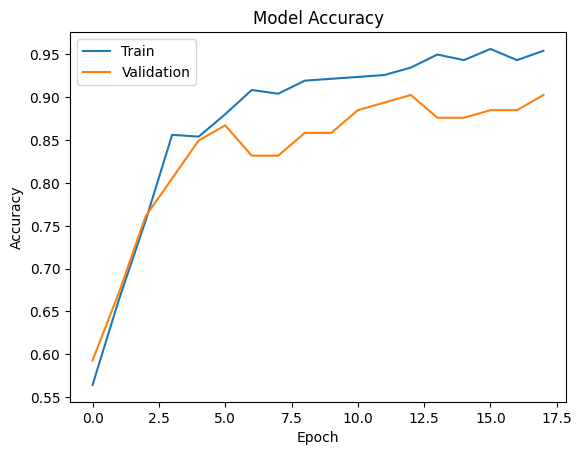

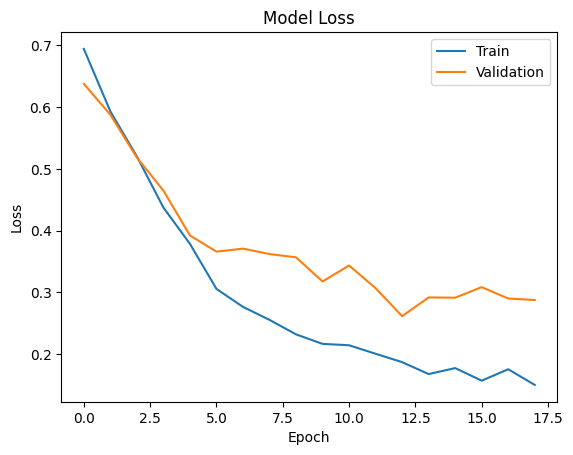

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [25]:
from google.colab import files
files.download("/content/drive/MyDrive/monkeypox_vgg16.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import tensorflow as tf

def build_model(hp):

    model = Sequential()

    num_conv_layers = hp.Int(
        'num_conv_layers',
        min_value=2,
        max_value=5
    )

    for i in range(num_conv_layers):

        filters = hp.Choice(
            f'filters_{i}',
            values=[32, 64, 128, 256]
        )

        if i == 0:
            model.add(
                Conv2D(
                    filters=filters,
                    kernel_size=(3,3),
                    activation='relu',
                    input_shape=(224,224,3)
                )
            )
        else:
            model.add(
                Conv2D(
                    filters=filters,
                    kernel_size=(3,3),
                    activation='relu'
                )
            )

        model.add(BatchNormalization())
        model.add(MaxPooling2D(2,2))

    model.add(GlobalAveragePooling2D())

    dense_units = hp.Choice(
        'dense_units',
        values=[64,128,256,512]
    )

    model.add(Dense(
        dense_units,
        activation='relu'
    ))

    dropout_rate = hp.Float(
        'dropout',
        min_value=0.2,
        max_value=0.6,
        step=0.1
    )

    model.add(Dropout(dropout_rate))

    model.add(Dense(
        1,
        activation='sigmoid'
    ))

    learning_rate = hp.Choice(
        'learning_rate',
        values=[
            1e-2,
            1e-3,
            1e-4,
            1e-5
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [28]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.6 MB/s eta 0:00:00


In [33]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,BatchNormalization,Dropout

In [37]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='tuner_results',
    project_name='monkeypox'
)

tuner.search(
    train_data,
    validation_data=val_data,
    epochs=10
)

Trial 10 Complete [00h 00m 25s]

Best val_accuracy So Far: 0.7433628439903259
Total elapsed time: 00h 33m 31s


In [38]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Conv Layers:",
      best_hp.get('num_conv_layers'))

print("Best Dense Units:",
      best_hp.get('dense_units'))

print("Best Dropout:",
      best_hp.get('dropout'))

print("Best Learning Rate:",
      best_hp.get('learning_rate'))

Best Conv Layers: 2
Best Dense Units: 128
Best Dropout: 0.30000000000000004
Best Learning Rate: 1e-05


In [39]:
best_model = tuner.get_best_models(1)[0]

history = best_model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 933ms/step - accuracy: 0.8410 - loss: 0.3771 - val_accuracy: 0.6106 - val_loss: 0.6649
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 612ms/step - accuracy: 0.8083 - loss: 0.4326 - val_accuracy: 0.5841 - val_loss: 0.6741
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 625ms/step - accuracy: 0.8453 - loss: 0.4407 - val_accuracy: 0.7611 - val_loss: 0.6202
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 736ms/step - accuracy: 0.8780 - loss: 0.3713 - val_accuracy: 0.7611 - val_loss: 0.6154
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 650ms/step - accuracy: 0.8540 - loss: 0.3586 - val_accuracy: 0.6549 - val_loss: 0.6456


In [40]:
loss, accuracy = best_model.evaluate(val_data)

print("Best Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5398 - loss: 0.6785
Best Accuracy: 0.5398229956626892


In [41]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

In [42]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [46]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [47]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6885 - loss: 0.6243 - val_accuracy: 0.5133 - val_loss: 0.6889
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 623ms/step - accuracy: 0.7386 - loss: 0.5194 - val_accuracy: 0.5133 - val_loss: 0.6905
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 591ms/step - accuracy: 0.7582 - loss: 0.5043 - val_accuracy: 0.5133 - val_loss: 0.6890
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 678ms/step - accuracy: 0.8017 - loss: 0.4331 - val_accuracy: 0.5133 - val_loss: 0.6870
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 613ms/step - accuracy: 0.8105 - loss: 0.4588 - val_accuracy: 0.5133 - val_loss: 0.6839
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 628ms/step - accuracy: 0.7821 - loss: 0.4326 - val_accuracy: 0.5133 - val_loss: 0.6819
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 675ms/step - accuracy: 0.8170 - loss: 0.4177 - val_accuracy: 0.6637 - val_loss: 0.6817
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 638ms/step - accuracy: 0.8083 - loss: 0.4123 - val_accuracy: 0

In [48]:
loss, accuracy = best_model.evaluate(val_data)

print("Best Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5310 - loss: 0.6863
Best Accuracy: 0.5309734344482422


In [49]:
import numpy as np

predictions = cnn_model.predict(val_data)
predictions = (predictions > 0.5).astype(int)

print(np.unique(predictions, return_counts=True))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 525ms/step
(array([0, 1]), array([42, 71]))


In [50]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.8453159332275391
0.48672565817832947
